Sinusoidal 位置编码：
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  3.10983593e-01  9.50415280e-01
   9.98334166e-02  9.95004165e-01  3.16175064e-02  9.99500042e-01
   9.99983333e-03  9.99950000e-01  3.16227239e-03  9.99995000e-01
   9.99999833e-04  9.99999500e-01  3.16227761e-04  9.99999950e-01]
 [ 9.09297427e-01 -4.16146837e-01  5.91127117e-01  8.06578410e-01
   1.98669331e-01  9.80066578e-01  6.32033979e-02  9.98000667e-01
   1.99986667e-02  9.99800007e-01  6.32451316e-03  9.99980000e-01
   1.99999867e-03  9.99998000e-01  6.32455490e-04  9.99999800e-01]
 [ 1.41120008e-01 -9.89992497e-01  8.12648897e-01  5.82753611e-01
   2.95520207e-01  9.55336489e-01  9.47260913e-02  9.95503374e-01
   2.99955002e-02  9.99550034e-01  9.48669068e-03  9.999

/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/IPython/core/pylabtools.py:170:

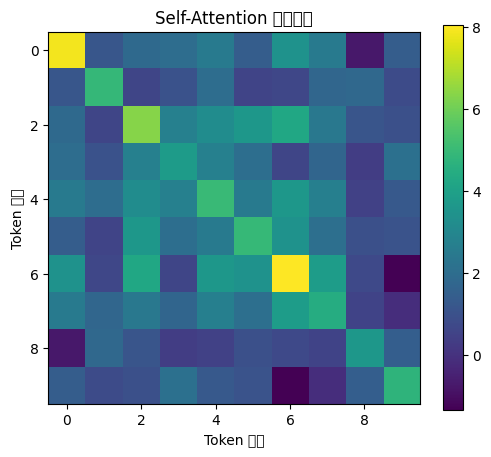

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_sinusoid_encoding_table(n_position, d_model):
    """
    生成 sinusoidal 位置编码矩阵.

    参数:
        n_position: 序列长度（位置数目）
        d_model: 嵌入维度

    返回:
        一个形状为 (n_position, d_model) 的 numpy 数组，其中每一行对应一个位置的编码。
    """
    def cal_angle(pos, i):
        return pos / np.power(10000, 2 * (i // 2) / d_model)

    # 初始化编码矩阵
    encoding_table = np.zeros((n_position, d_model))
    for pos in range(n_position):
        for i in range(d_model):
            encoding_table[pos, i] = cal_angle(pos, i)

    # 对偶数和奇数索引的维度分别应用 sin 和 cos 函数
    encoding_table[:, 0::2] = np.sin(encoding_table[:, 0::2])  # 偶数索引
    encoding_table[:, 1::2] = np.cos(encoding_table[:, 1::2])  # 奇数索引
    return encoding_table

if __name__ == '__main__':
    # 设置序列长度和嵌入维度
    seq_len = 10     # 序列中 token 的数量
    d_model = 16     # 嵌入维度

    # 生成位置编码
    pos_encoding = get_sinusoid_encoding_table(seq_len, d_model)
    print("Sinusoidal 位置编码：")
    print(pos_encoding)

    # 模拟 token 嵌入（例如可以看作是查词表得到的嵌入），这里使用随机数表示
    token_embeddings = np.random.randn(seq_len, d_model)
    print("\nToken 嵌入：")
    print(token_embeddings)

    # 将 token 嵌入与位置编码相加，得到融合了语义和位置信息的表示
    combined_embeddings = token_embeddings + pos_encoding
    print("\n融合后的嵌入（Token 嵌入 + 位置编码）：")
    print(combined_embeddings)

    # --- 简单演示 self-attention 的计算 ---
    # 这里为了简单起见，将 query、key、value 都直接设为融合后的嵌入
    # 计算注意力得分矩阵：scores = Q * K^T / sqrt(d_model)
    scores = combined_embeddings @ combined_embeddings.T / np.sqrt(d_model)
    print("\nSelf-Attention 得分矩阵：")
    print(scores)

    # 可视化注意力得分矩阵
    plt.figure(figsize=(6, 5))
    plt.imshow(scores, cmap='viridis')
    plt.title("Self-Attention 得分矩阵")
    plt.xlabel("Token 索引")
    plt.ylabel("Token 索引")
    plt.colorbar()
    plt.show()
